In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

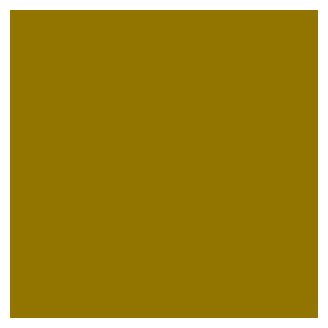

In [2]:
# Create a background that randomly samples a color from the Lab color space
lab_pixel = np.zeros((1, 1, 3), dtype=np.uint8)
lab_pixel[0,0] = [np.random.randint(255), np.random.randint(255), np.random.randint(255)]  # Example Lab color
# note: while LAB color space has L in [0, 100] and a,b in [-128, 127], OpenCV uses a scaled version where L is in [0, 255]
#  and a,b are in [0, 255]
lab_pixel[::,0]
rgb_pixel = cv2.cvtColor(lab_pixel, cv2.COLOR_LAB2RGB)

swatch = np.zeros((200, 200, 3), dtype=np.uint8)
swatch[:, :] = rgb_pixel[0, 0]

plt.figure(figsize=(4, 4))
plt.imshow(swatch)
plt.axis("off")
plt.show()

In [3]:
lab_pixel[0,0] = [np.random.randint(100), np.random.randint(255), np.random.randint(255)]  # Example Lab color
lab_pixel[::,0]

array([[ 46, 113,  40]], dtype=uint8)

# https://stackoverflow.com/questions/71865493/is-it-possible-to-create-a-random-shape-on-an-image-in-python
import cv2
import skimage.exposure
import numpy as np
from numpy.random import default_rng

# read input image
img = cv2.imread('lena.jpg')
height, width = img.shape[:2]

# define random seed to change the pattern
seedval = 75
rng = default_rng(seed=seedval)

# create random noise image
noise = rng.integers(0, 255, (height,width), np.uint8, True)

# blur the noise image to control the size
blur = cv2.GaussianBlur(noise, (0,0), sigmaX=15, sigmaY=15, borderType = cv2.BORDER_DEFAULT)

# stretch the blurred image to full dynamic range
stretch = skimage.exposure.rescale_intensity(blur, in_range='image', out_range=(0,255)).astype(np.uint8)

# threshold stretched image to control the size
thresh = cv2.threshold(stretch, 175, 255, cv2.THRESH_BINARY)[1]

# apply morphology open and close to smooth out and make 3 channels
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9,9))
mask = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
mask = cv2.merge([mask,mask,mask])

# add mask to input
result1 = cv2.add(img, mask)

# use canny edge detection on mask
edges = cv2.Canny(mask,50,255)

# thicken edges and make 3 channel
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
edges = cv2.morphologyEx(edges, cv2.MORPH_DILATE, kernel)
edges = cv2.merge([edges,edges,edges])

# merge edges with result1 (make black in result where edges are white)
result2 = result1.copy()
result2[np.where((edges == [255,255,255]).all(axis=2))] = [0,0,0]

# add noise to result where mask is white
noise = cv2.merge([noise,noise,noise])
result3 = result2.copy()
result3 = np.where(mask==(255,255,255), noise, result3)

# save result
cv2.imwrite('lena_random_blobs1.jpg', result1)
cv2.imwrite('lena_random_blobs2.jpg', result2)
cv2.imwrite('lena_random_blobs3.jpg', result3)

# show results
cv2.imshow('noise', noise)
cv2.imshow('blur', blur)
cv2.imshow('stretch', stretch)
cv2.imshow('thresh', thresh)
cv2.imshow('mask', mask)
cv2.imshow('edges', edges)
cv2.imshow('result1', result1)
cv2.imshow('result2', result2)
cv2.imshow('result3', result3)
cv2.waitKey(0)
cv2.destroyAllWindows()

- https://docs.opencv.org/3.4/df/d61/tutorial_random_generator_and_text.html
- https://docs.opencv.org/4.x/df/d9d/tutorial_py_colorspaces.html

In [10]:
from numpy.random import default_rng


def _sample_ceramic_bg(rng):
    """Sample a plausible ceramic matrix color in LAB; return BGR uint8 tuple."""
    if rng.random() < 0.1:  # 10% chance for dark grey
        # Dark grey in LAB (low L, neutral a/b)
        L = rng.integers(30, 70)
        a = rng.integers(120, 135)
        b = rng.integers(120, 135)
    else:
        L = rng.integers(120, 220)
        a = rng.integers(128, 165)
        b = rng.integers(135, 175)
    lab = np.array([[[L, a, b]]], dtype=np.uint8)
    bgr = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)
    return tuple(int(c) for c in bgr[0, 0])


def _blob_mask(rng, radius):
    """Soft lumpy blob on a local canvas of side ~2*radius."""
    side = 2 * radius + 4
    noise = rng.integers(0, 255, (side, side), dtype=np.uint8)
    blur = cv2.GaussianBlur(noise, (0, 0), sigmaX=radius / 3.0, sigmaY=radius / 3.0)
    stretch = cv2.normalize(blur, None, 0, 255, cv2.NORM_MINMAX)
    _, mask = cv2.threshold(stretch, 175, 255, cv2.THRESH_BINARY)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    return mask


def _polygon_mask(rng, radius):
    """Roughly regular polygon with jittered vertices."""
    side = 2 * radius + 4
    mask = np.zeros((side, side), dtype=np.uint8)
    n_sides = int(rng.integers(3, 9))
    rot = rng.uniform(0, 2 * np.pi)
    cx, cy = side // 2, side // 2
    angles = np.linspace(0, 2 * np.pi, n_sides, endpoint=False) + rot
    jitter = rng.uniform(0.8, 1.2, size=n_sides)
    xs = (cx + radius * jitter * np.cos(angles)).astype(np.int32)
    ys = (cy + radius * jitter * np.sin(angles)).astype(np.int32)
    pts = np.stack([xs, ys], axis=1)
    cv2.fillPoly(mask, [pts], 255)
    return mask


def _void_mask(rng, radius):
    """Wonkier outline than _blob_mask: higher-frequency noise, less smoothing."""
    side = 2 * radius + 4
    noise = rng.integers(0, 255, (side, side), dtype=np.uint8)
    blur = cv2.GaussianBlur(noise, (0, 0), sigmaX=radius / 5.0, sigmaY=radius / 5.0)
    stretch = cv2.normalize(blur, None, 0, 255, cv2.NORM_MINMAX)
    _, mask = cv2.threshold(stretch, 160, 255, cv2.THRESH_BINARY)
    # keep only the connected component nearest the canvas center
    n_lbl, labels = cv2.connectedComponents(mask)
    if n_lbl > 1:
        center_lbl = labels[side // 2, side // 2]
        if center_lbl == 0:
            ys, xs = np.where(labels > 0)
            if len(xs):
                d = (xs - side // 2) ** 2 + (ys - side // 2) ** 2
                idx = int(np.argmin(d))
                center_lbl = labels[ys[idx], xs[idx]]
        if center_lbl != 0:
            mask = np.where(labels == center_lbl, 255, 0).astype(np.uint8)
    return mask


# Material palettes for non-void inclusions, in OpenCV-scaled LAB.
# Each entry is (L_range, a_range, b_range); a,b are centered at 128 (neutral),
# higher a = redder, higher b = yellower.
_INCLUSION_PALETTES = [
    ((210, 250), (118, 135), (118, 138)),  # white shell / limestone
    ((10, 60),   (120, 135), (118, 138)),  # black sand / basalt / charcoal
    ((90, 140),  (120, 134), (120, 134)),  # mid grey stone
    ((90, 160),  (140, 165), (140, 170)),  # terracotta grog
    ((40, 90),   (130, 150), (130, 160)),  # dark brown organics / iron-rich
]


def _sample_inclusion_color(bg_bgr, kind, rng):
    """Sample a BGR color. Voids stay matrix-hued but darker; other kinds draw from material palettes."""
    if kind == "void":
        bgr_arr = np.array([[bg_bgr]], dtype=np.uint8)
        lab = cv2.cvtColor(bgr_arr, cv2.COLOR_BGR2LAB).astype(np.int32)
        lab[0, 0, 0] = max(0, lab[0, 0, 0] - int(rng.integers(60, 121)))
        bgr = cv2.cvtColor(lab.astype(np.uint8), cv2.COLOR_LAB2BGR)
        return tuple(int(c) for c in bgr[0, 0])
    L_r, a_r, b_r = _INCLUSION_PALETTES[int(rng.integers(0, len(_INCLUSION_PALETTES)))]
    L = int(rng.integers(L_r[0], L_r[1] + 1))
    a = int(rng.integers(a_r[0], a_r[1] + 1))
    b = int(rng.integers(b_r[0], b_r[1] + 1))
    lab = np.array([[[L, a, b]]], dtype=np.uint8)
    bgr = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)
    return tuple(int(c) for c in bgr[0, 0])


_KINDS = np.array(["blob", "polygon", "void"])
_KIND_WEIGHTS = np.array([0.60, 0.25, 0.15])
_MAX_TRIES = 50


def generate_ceramic_image(image_size, n_inclusions, size_range, seed):
    """Create a synthetic ceramic image with non-overlapping inclusions.

    Parameters
    ----------
    image_size : (H, W) in pixels
    n_inclusions : target count of inclusions to place
    size_range : (min_radius, max_radius) in pixels
    seed : RNG seed for reproducibility

    Returns
    -------
    (image_bgr, label_mask_int32, metadata_dict)
    """
    H, W = image_size
    rng = default_rng(seed)
    bg = _sample_ceramic_bg(rng)
    image = np.full((H, W, 3), bg, dtype=np.uint8)
    label_mask = np.zeros((H, W), dtype=np.int32)
    inclusions = []
    skipped = 0
    rmin, rmax = size_range

    for i in range(1, n_inclusions + 1):
        radius = int(rng.integers(rmin, rmax + 1))
        kind = str(rng.choice(_KINDS, p=_KIND_WEIGHTS))
        if kind == "blob":
            shape = _blob_mask(rng, radius)
        elif kind == "polygon":
            shape = _polygon_mask(rng, radius)
        else:
            shape = _void_mask(rng, radius)
        sh, sw = shape.shape
        if sh >= H or sw >= W or shape.sum() == 0:
            skipped += 1
            continue
        color = _sample_inclusion_color(bg, kind, rng)

        placed = False
        for _ in range(_MAX_TRIES):
            # entire stamp strictly inside the frame, so shapes never touch the border
            x0 = int(rng.integers(0, W - sw))
            y0 = int(rng.integers(0, H - sh))
            region = label_mask[y0:y0 + sh, x0:x0 + sw]
            if np.any((shape > 0) & (region > 0)):
                continue
            ys, xs = np.where(shape > 0)
            image[y0 + ys, x0 + xs] = color
            label_mask[y0 + ys, x0 + xs] = i
            cx = x0 + int(xs.mean())
            cy = y0 + int(ys.mean())
            inclusions.append({
                "id": i,
                "kind": kind,
                "center": (cx, cy),
                "radius": radius,
                "color_bgr": color,
            })
            placed = True
            break
        if not placed:
            skipped += 1

    metadata = {
        "seed": seed,
        "image_size": (H, W),
        "background_bgr": bg,
        "inclusions": inclusions,
        "skipped": skipped,
    }
    return image, label_mask, metadata


def generate_ceramic_image_batch(n_images, seeds, image_size, n_inclusions, size_range):
    """Run generate_ceramic_image once per seed. Requires len(seeds) == n_images."""
    if len(seeds) != n_images:
        raise ValueError(f"len(seeds)={len(seeds)} does not match n_images={n_images}")
    return [
        generate_ceramic_image(image_size, n_inclusions, size_range, s)
        for s in seeds
    ]

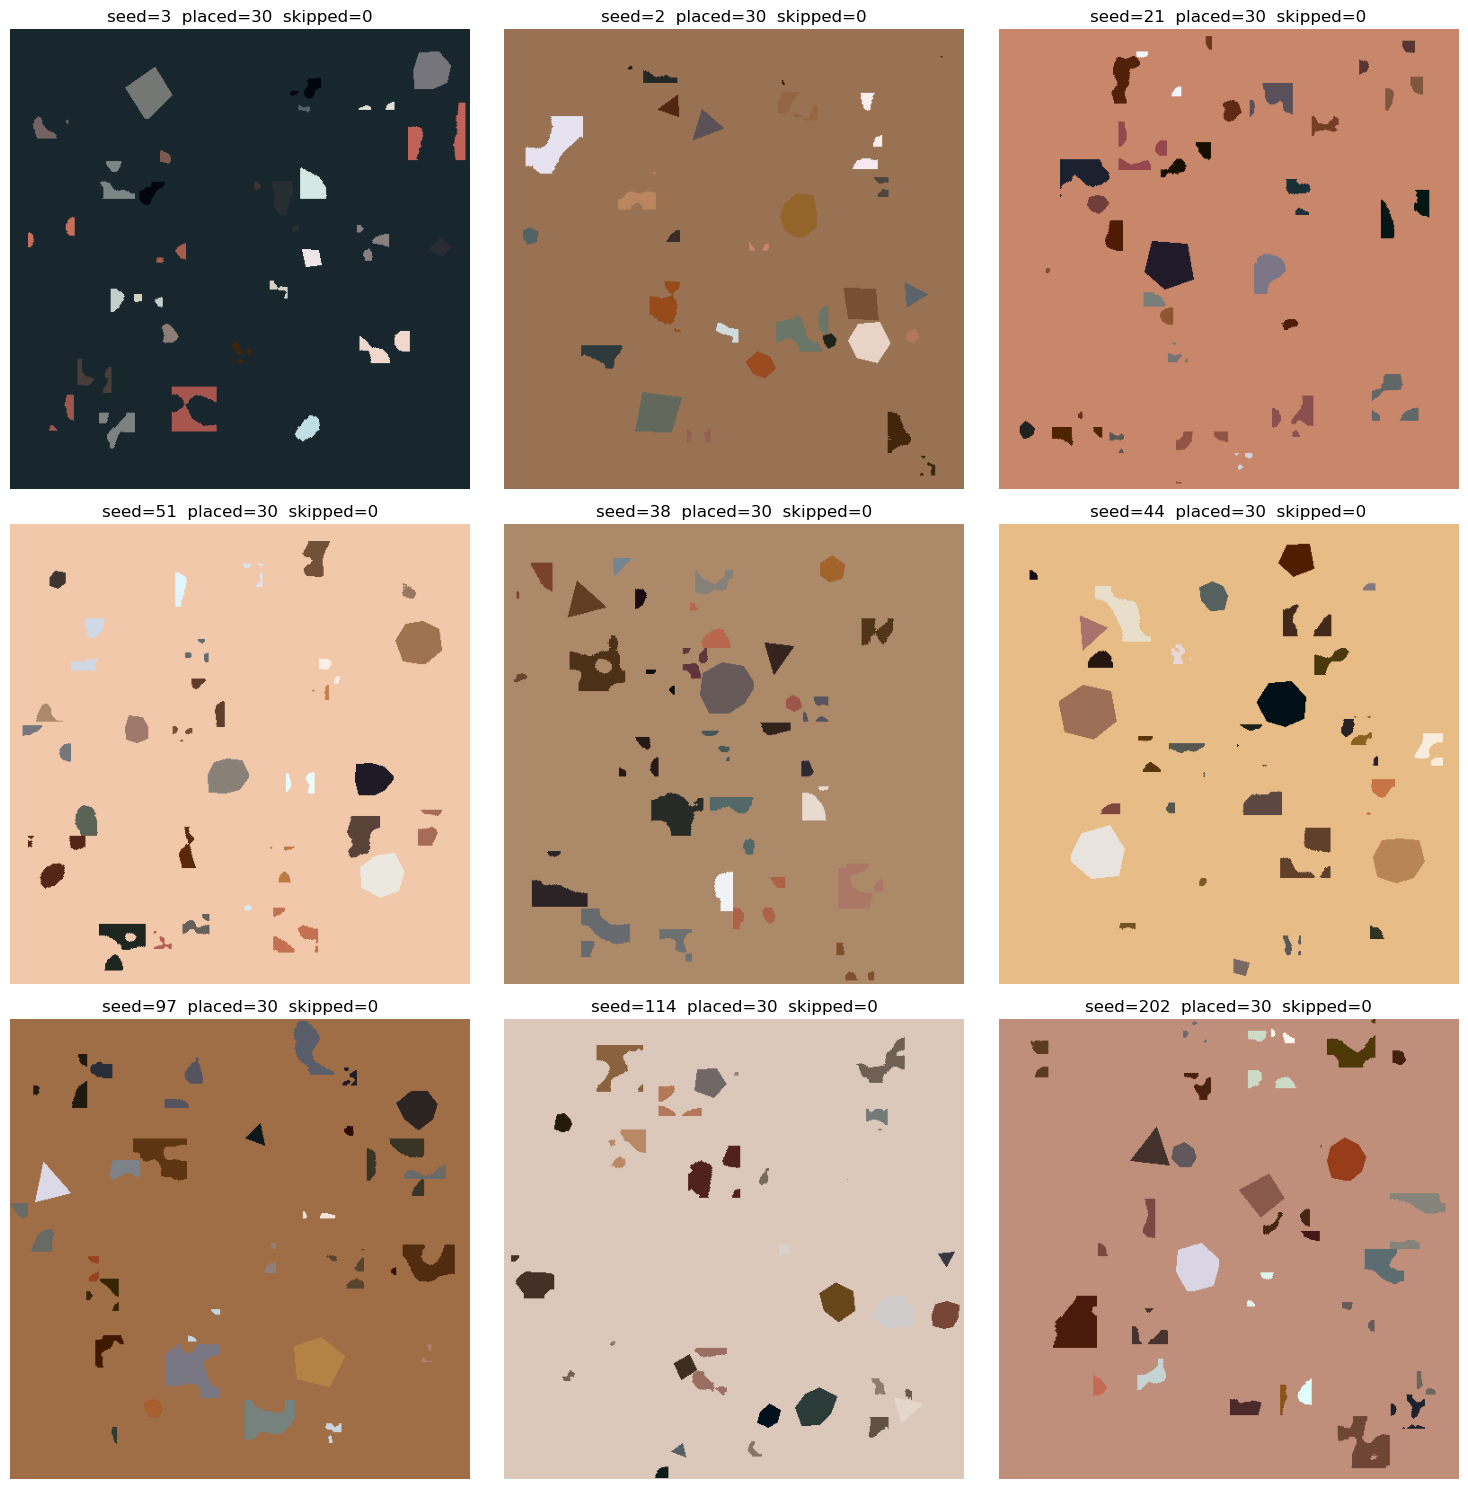

In [17]:
results = generate_ceramic_image_batch(
    n_images= 9,
    seeds=[3, 2 ,21, 51, 38, 44, 97, 114, 202],
    image_size=(512, 512),
    n_inclusions=30,
    size_range=(8, 30),
)

fig, axes = plt.subplots(3, 3, figsize=(15, 15))
for ax, (img, mask, meta) in zip(axes.flat, results):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(f"seed={meta['seed']}  placed={len(meta['inclusions'])}  skipped={meta['skipped']}")
    ax.axis("off")
plt.tight_layout()
plt.show()